# Movie Box-Office Success Predictor — Exploratory Data Analysis

**Author:** Bennett Speicher
**Course:** DATA 606 Capstone (Summer 2026), UMBC — Dr. Chaojie (Jay) Wang

This notebook explores the **TMDB 5000 Movie Dataset** to support a capstone project that predicts whether a film
will be a **financial success** from information knowable *before* release.

**Definition of success (target):** a movie is a *success* if its worldwide box-office
**revenue is at least 2× its production budget** (`revenue >= 2 * budget`). This 2× rule is a standard
industry proxy for theatrical break-even: studios typically spend roughly half-to-equal the production
budget again on marketing, and keep only ~50% of box-office gross after the theaters' cut — so a film
must gross about twice its budget to make money.

*Caveat:* TMDB `revenue` is worldwide box-office gross and `budget` excludes marketing, so this target is a
well-grounded **proxy** for profitability, not exact accounting profit.


In [1]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import plotly.io as pio

# Render Plotly figures as static PNGs so they display on GitHub's notebook viewer.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 30)
pd.options.display.float_format = lambda x: f"{x:,.2f}"


## 1. Load the data

In [2]:
df = pd.read_csv("../data/tmdb_5000_movies.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.20,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.90,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.30,4466


## 2. Columns, types, and missing values

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.to_frame("missing_count").assign(missing_pct=(missing/len(df)*100).round(1))


,missing_count,missing_pct
homepage,3091,64.40
tagline,844,17.60
overview,3,0.10
runtime,2,0.00
release_date,1,0.00


## 3. Cleaning and defining the target

Steps:
1. Keep only **released** films.
2. Keep only rows with a **real budget and revenue** (`> 0`). Many TMDB rows store `0` to mean "unknown,"
   which would corrupt an ROI calculation.
3. Parse the JSON-encoded columns (e.g., `genres`).
4. Engineer features: `roi`, `profit`, release `year`/`month`, primary `genre`, and the binary `success` label.


In [5]:
def parse_names(json_str):
    """Extract the list of 'name' values from a TMDB JSON-encoded cell."""
    try:
        return [d["name"] for d in json.loads(json_str)]
    except Exception:
        return []

clean = df[df["status"] == "Released"].copy()
clean = clean[(clean["budget"] > 0) & (clean["revenue"] > 0)].copy()

clean["genre_list"] = clean["genres"].apply(parse_names)
clean["primary_genre"] = clean["genre_list"].apply(lambda g: g[0] if g else "Unknown")
clean["n_genres"] = clean["genre_list"].apply(len)
clean["n_production_companies"] = clean["production_companies"].apply(lambda s: len(parse_names(s)))
clean["n_spoken_languages"] = clean["spoken_languages"].apply(lambda s: len(parse_names(s)))

clean["release_date"] = pd.to_datetime(clean["release_date"], errors="coerce")
clean["year"] = clean["release_date"].dt.year
clean["month"] = clean["release_date"].dt.month

clean["roi"] = clean["revenue"] / clean["budget"]
clean["profit"] = clean["revenue"] - clean["budget"]
clean["success"] = (clean["revenue"] >= 2 * clean["budget"]).astype(int)

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning : {len(clean):,}  ({len(clean)/len(df)*100:.1f}% retained)")
print(f"Year range          : {int(clean['year'].min())}–{int(clean['year'].max())}")
clean[["title","budget","revenue","roi","primary_genre","year","success"]].head()


Rows before cleaning: 4,803
Rows after cleaning : 3,228  (67.2% retained)
Year range          : 1916–2016


,title,budget,revenue,roi,primary_genre,year,success
0,Avatar,237000000,2787965087,11.76,Action,2009,1
1,Pirates of the Caribbean: At World's End,300000000,961000000,3.20,Adventure,2007,1
2,Spectre,245000000,880674609,3.59,Action,2015,1
3,The Dark Knight Rises,250000000,1084939099,4.34,Action,2012,1
4,John Carter,260000000,284139100,1.09,Action,2012,0


## 4. The target variable — class balance

A balanced target makes for a cleaner classification problem and more meaningful metrics.

success
Successful (>=2x)       1809
Not Successful (<2x)    1419
Name: count, dtype: int64

Success rate: 56.0%


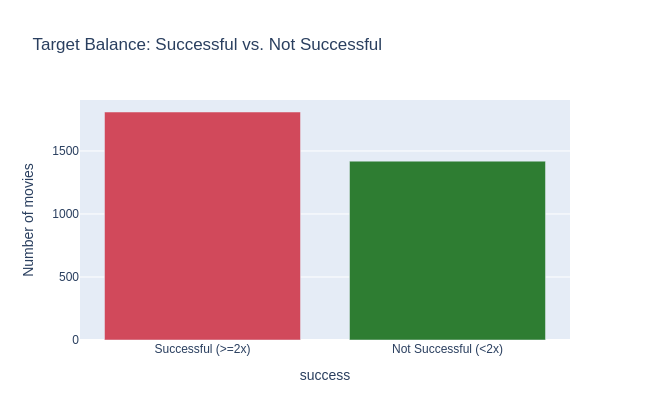

In [6]:
counts = clean["success"].map({0:"Not Successful (<2x)", 1:"Successful (>=2x)"}).value_counts()
print(counts)
print(f"\nSuccess rate: {clean['success'].mean()*100:.1f}%")
fig = px.bar(counts, x=counts.index, y=counts.values,
             title="Target Balance: Successful vs. Not Successful",
             labels={"x":"", "y":"Number of movies"}, color=counts.index,
             color_discrete_sequence=["#d1495b","#2e7d32"])
fig.update_layout(showlegend=False, width=650, height=420)
fig.show()


## 5. Distributions of key numeric features

Budget and revenue are highly right-skewed, so we view them on a log scale.

In [7]:
clean[["budget","revenue","roi","runtime","popularity","vote_average","vote_count"]].describe()


,budget,revenue,roi,runtime,popularity,vote_average,vote_count
count,"3,228.00","3,228.00","3,228.00","3,228.00","3,228.00","3,228.00","3,228.00"
mean,"40,666,419.51","121,280,256.28","2,955.74",110.72,29.04,6.31,977.59
std,"44,398,404.53","186,319,669.51","150,633.42",20.97,36.17,0.87,"1,414.43"
min,1.00,5.00,0.00,41.00,0.02,0.00,0.00
25%,"10,500,000.00","17,000,000.00",1.02,96.00,10.47,5.80,178.00
50%,"25,000,000.00","55,191,503.00",2.30,107.00,20.41,6.30,471.00
75%,"55,000,000.00","146,343,449.50",4.42,121.00,37.34,6.90,"1,148.00"
max,"380,000,000.00","2,787,965,087.00","8,500,000.00",338.00,875.58,8.50,"13,752.00"


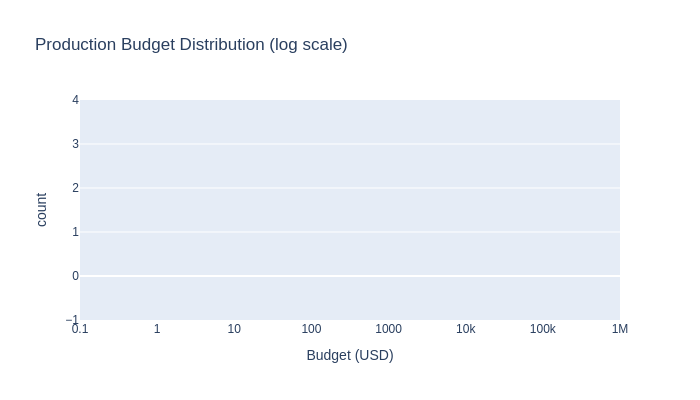

In [8]:
fig = px.histogram(clean, x="budget", nbins=50, title="Production Budget Distribution (log scale)",
                   labels={"budget":"Budget (USD)"})
fig.update_xaxes(type="log")
fig.update_layout(width=700, height=400)
fig.show()


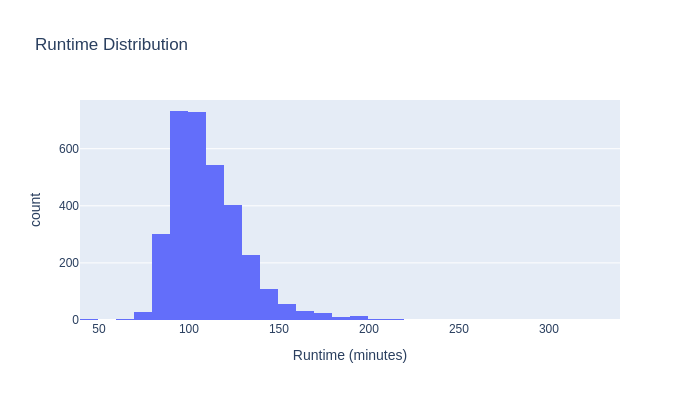

In [9]:
fig = px.histogram(clean, x="runtime", nbins=40, title="Runtime Distribution",
                   labels={"runtime":"Runtime (minutes)"})
fig.update_layout(width=700, height=400)
fig.show()


## 6. Budget vs. revenue

The dashed line is break-even under our definition (`revenue = 2 × budget`). Points above it are successes.

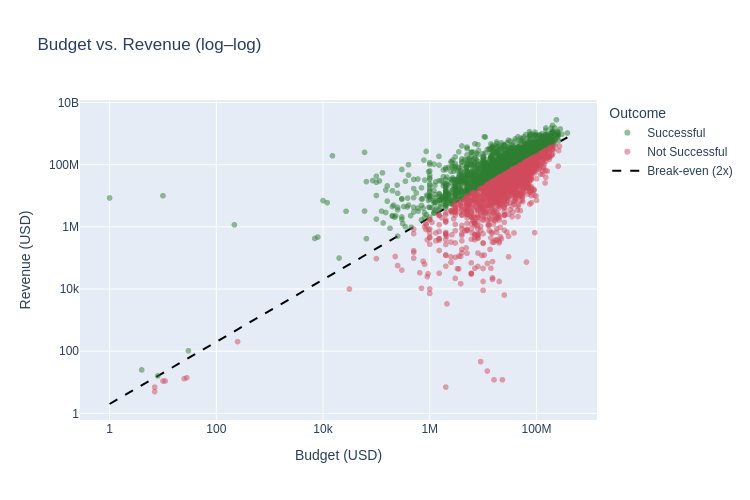

In [10]:
import plotly.graph_objects as go
fig = px.scatter(clean, x="budget", y="revenue", color=clean["success"].map({0:"Not Successful",1:"Successful"}),
                 opacity=0.5, title="Budget vs. Revenue (log–log)",
                 labels={"budget":"Budget (USD)","revenue":"Revenue (USD)","color":"Outcome"},
                 color_discrete_map={"Not Successful":"#d1495b","Successful":"#2e7d32"})
xs = [clean["budget"].min(), clean["budget"].max()]
fig.add_trace(go.Scatter(x=xs, y=[2*xs[0], 2*xs[1]], mode="lines",
                         line=dict(dash="dash", color="black"), name="Break-even (2x)"))
fig.update_xaxes(type="log"); fig.update_yaxes(type="log")
fig.update_layout(width=750, height=500)
fig.show()


## 7. Success rate by genre

Does a film's primary genre relate to its odds of success?

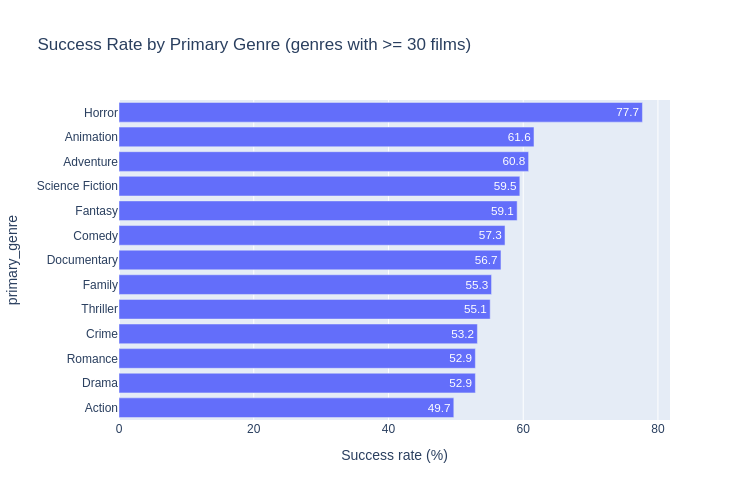

,success_rate,n
primary_genre,,
Horror,77.70,197
Animation,61.60,99
Adventure,60.80,288
Science Fiction,59.50,79
Fantasy,59.10,93
Comedy,57.30,634
Documentary,56.70,30
Family,55.30,38
Thriller,55.10,118


In [11]:
genre_stats = (clean.groupby("primary_genre")
               .agg(success_rate=("success","mean"), n=("success","size"))
               .query("n >= 30").sort_values("success_rate", ascending=False))
genre_stats["success_rate"] = (genre_stats["success_rate"]*100).round(1)
fig = px.bar(genre_stats, x="success_rate", y=genre_stats.index, orientation="h",
             title="Success Rate by Primary Genre (genres with >= 30 films)",
             labels={"success_rate":"Success rate (%)","y":"Primary genre"},
             text="success_rate")
fig.update_layout(width=750, height=500, yaxis={"categoryorder":"total ascending"})
fig.show()
genre_stats


## 8. Success rate by release month

Summer and holiday releases are often considered prime windows — does the data agree?

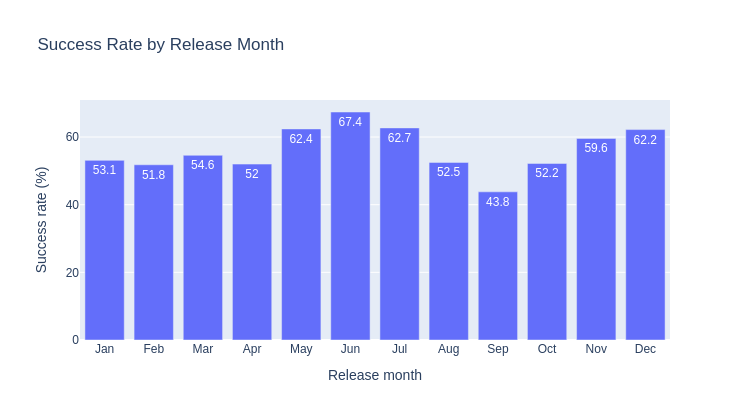

In [12]:
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
m = (clean.dropna(subset=["month"]).groupby("month")
     .agg(success_rate=("success","mean"), n=("success","size")).reset_index())
m["month_name"] = m["month"].map(month_names)
m["success_rate"] = (m["success_rate"]*100).round(1)
fig = px.bar(m, x="month_name", y="success_rate", title="Success Rate by Release Month",
             labels={"month_name":"Release month","success_rate":"Success rate (%)"}, text="success_rate")
fig.update_layout(width=750, height=420)
fig.show()


## 9. Correlations among numeric features

Which numeric variables move together, and which relate to success?

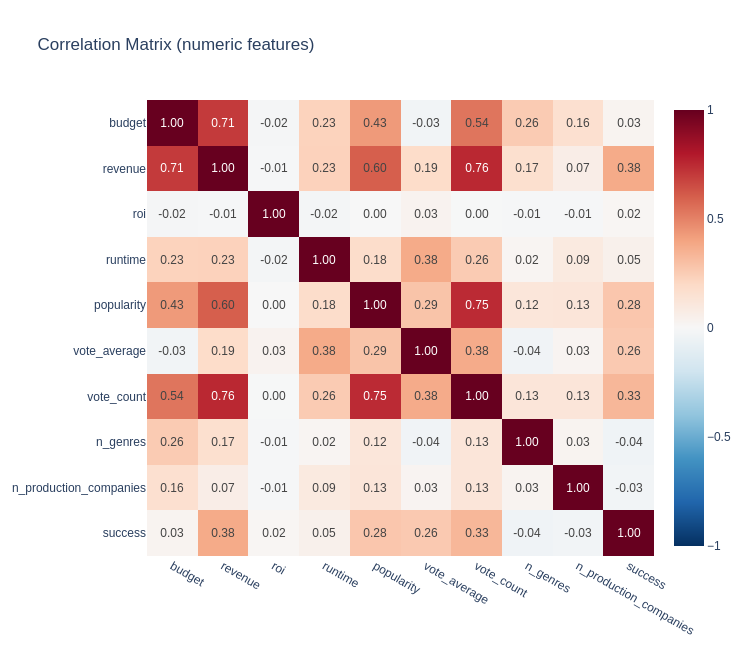

In [13]:
num_cols = ["budget","revenue","roi","runtime","popularity","vote_average","vote_count",
            "n_genres","n_production_companies","success"]
corr = clean[num_cols].corr()
fig = px.imshow(corr, text_auto=".2f", aspect="auto", color_continuous_scale="RdBu_r",
                zmin=-1, zmax=1, title="Correlation Matrix (numeric features)")
fig.update_layout(width=750, height=650)
fig.show()


## 10. Key takeaways and next steps

**What the EDA shows**
- After keeping released films with a real budget and revenue, **~3,200 movies** (≈67% of the raw data) remain — a solid sample spanning 1916–2016.
- Under the 2× definition, the target is **well balanced** (~56% success), which is ideal for classification.
- **Budget** and **vote_count/popularity** show the clearest relationships with revenue and success; budget alone is informative but far from deterministic.
- **Genre** and **release month** show meaningful variation in success rates — useful predictive signal.

**Data quality notes**
- `0` values in budget/revenue mean "unknown" and were removed; `homepage` and `tagline` are sparsely populated and will be dropped or converted to simple has/has-not flags.
- JSON columns (`genres`, `production_companies`, etc.) were parsed into usable features.

**Next steps (modeling phase)**
- Engineer pre-release features only (no leakage): budget, genre, runtime, release month, language, production-company count.
- Note: `revenue`, `roi`, `profit`, `popularity`, `vote_average`, and `vote_count` are **post-release** and must be excluded from the predictive feature set (they wouldn't be known before release).
- Train and compare classification models (e.g., logistic regression, random forest, gradient boosting) with an 80/20 train/test split.
- Deploy the chosen model in a Streamlit app where a user enters a hypothetical film's pre-release attributes to get a predicted success probability.
